In [30]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt

1. Dataset overview

2. Missing dates

3. Missing observations

4. Price distributions

5. Volume distributions

6. Largest daily moves

7. Random ticker inspection

8. Save conclusions

## Load dataset

In [31]:
lf = pl.scan_parquet('../data/processed/prices.parquet')

## Random inspection

In [168]:
ticker = lf.select(
    c('ticker')
    .unique()
    .sample(1)
).collect()[0, 0]
print('Description of {:}'.format(ticker))
lf.filter(
    c('ticker').is_in([ticker])
).describe()

Description of AES


statistic,ticker,date,open,high,low,close,volume,logret
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""6667""","""6667""",6667.0,6667.0,6667.0,6667.0,6667.0,6666.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,1.0
"""mean""",null,"""2013-04-03 13:28:00.935953""",16.608,16.856936,16.335585,11.799177,5.6274e6,-0.000067
"""std""",null,null,9.889117,10.066163,9.664858,6.786493,4.1421e6,0.031751
"""min""","""AES""","""2000-01-03""",1.0,1.09,0.92,0.598938,337500.0,-0.682891
"""25%""",null,"""2006-08-21""",11.34,11.47,11.21,7.748358,3.1092e6,-0.011442
"""50%""",null,"""2013-04-05""",13.89,14.04,13.7,9.664963,4.8142e6,0.000691
"""75%""",null,"""2019-11-15""",18.93,19.24,18.700001,14.203323,6.9725e6,0.01239
"""max""","""AES""","""2026-07-08""",70.75,72.8125,69.625,44.526257,8.02096e7,0.343771


## Global stats

In [96]:
print('Number of unique tickers, nan prices, null prices, infinite prices: {:}, {:}, {:}, {:}'.format( 
lf.select(
    c('ticker').n_unique()
).collect()[0, 0],
lf.select(
    c('close').is_nan().sum()
).collect()[0, 0],
lf.select(
    c('close').is_null().sum()
).collect()[0, 0],
lf.select(
    c('close').is_infinite().sum()
).collect()[0, 0]
))

Number of unique tickers, nan prices, null prices, infinite prices: 501, 0, 0, 0


In [ ]:
lf.describe()

statistic,ticker,date,open,high,low,close,volume
str,str,str,f64,f64,f64,f64,f64
"""count""","""2917517""","""2917517""",2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917517e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2014-01-27 09:58:18.835345""",85.111451,86.11896,84.082275,74.978281,8.5368e6
"""std""",null,null,198.358845,200.748997,195.980598,195.59945,4.7475e7
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,0.0
"""25%""",null,"""2007-09-25""",23.629999,23.95652,23.299999,16.2519,953400.0
"""50%""",null,"""2014-06-23""",45.66,46.189999,45.119999,34.29525,2.23771e6
"""75%""",null,"""2020-08-19""",89.559998,90.540001,88.548111,77.082573,5.4445e6
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9


## Plots

In [140]:
tickers = lf.select(
    c('ticker')
    .unique()
    .sample(12)
).collect().to_pandas()

df = lf.filter(
    c('ticker').is_in(tickers.iloc[:, 0].to_list())
).collect()

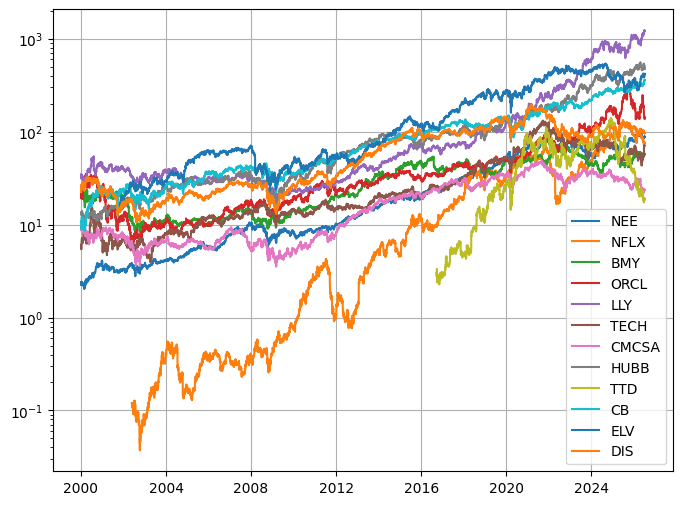

In [141]:
f, ax = plt.subplots(1, figsize=(8, 6))
plt.yscale('log') 
for ticker in df['ticker'].unique():
    plt.plot(df.filter(c('ticker').is_in([ticker]))['date'], 
             df.filter(c('ticker').is_in([ticker]))['close'], label=ticker)
plt.legend();plt.grid();

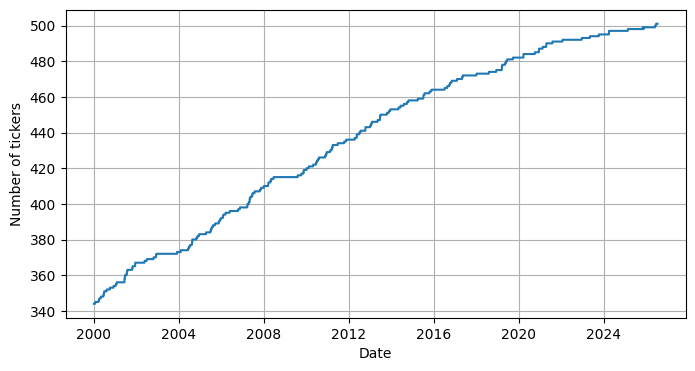

In [52]:
temp = (
    lf.group_by("date")
    .agg(c('ticker').n_unique())
).collect().sort('date')

f, ax = plt.subplots(1, figsize=(8, 4))
plt.plot(temp['date'], temp['ticker'])
plt.xlabel('Date'); plt.ylabel('Number of tickers'); plt.grid();

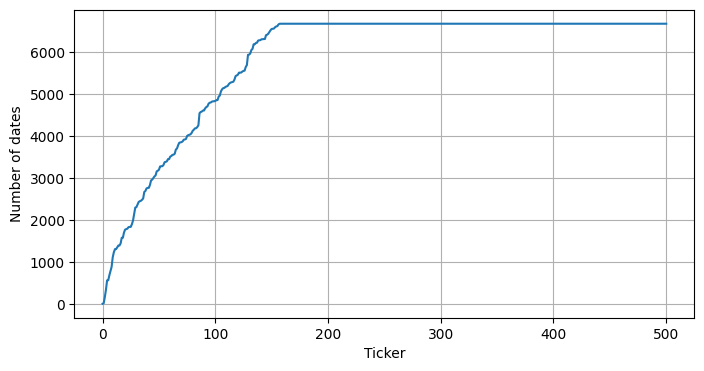

In [105]:
temp = (
    lf.group_by('ticker').agg(c('date').len())
).collect()

f, ax = plt.subplots(1, figsize=(8, 4))
plt.plot(temp['date'].sort())
plt.xlabel('Ticker'); plt.ylabel('Number of dates'); plt.grid();

##  Missing dates

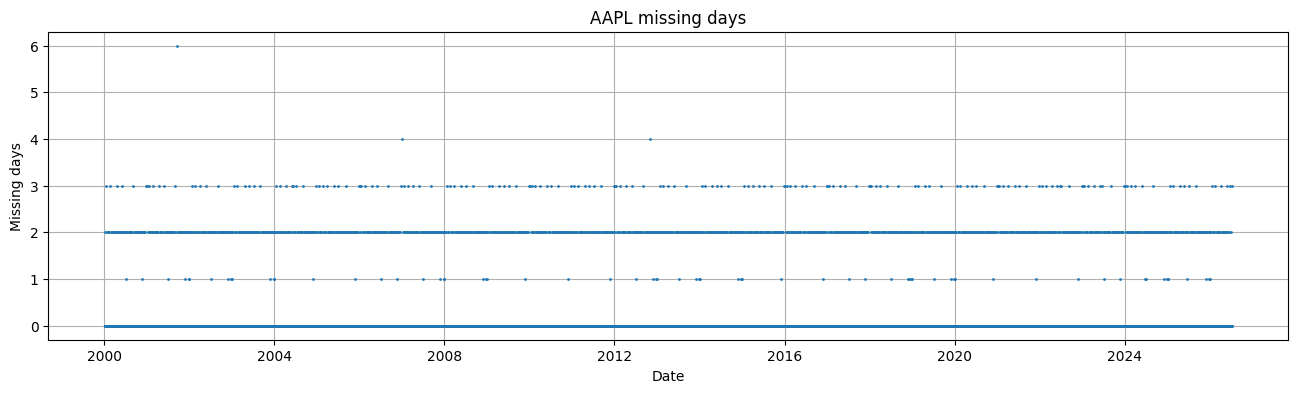

In [135]:
ticker = 'AAPL'
temp = lf.filter(
    c('ticker').is_in([ticker])
).select(
    c('date'),
    (c('date').diff().dt.total_days() - 1).alias('missing_days')
).collect()

f, ax = plt.subplots(1, figsize=(16, 4))
plt.plot(temp['date'], temp['missing_days'], 'o', markersize='1')
plt.xlabel('Date'); plt.ylabel('Missing days'); plt.grid();plt.title(f'{ticker} missing days');

## Volume inspection

In [150]:
tickers = lf.select(
    c('ticker')
    .unique()
    .sample(10)
).collect().to_pandas()

df = lf.filter(
    c('ticker').is_in(tickers.iloc[:, 0].to_list())
).collect()

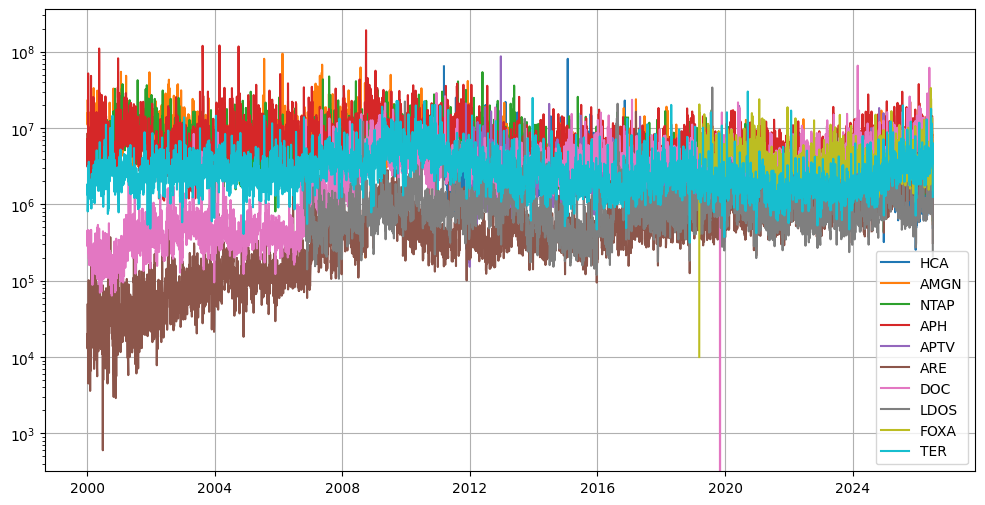

In [151]:
f, ax = plt.subplots(1, figsize=(12, 6))
plt.yscale('log') 
for ticker in df['ticker'].unique():
    plt.plot(df.filter(c('ticker').is_in([ticker]))['date'], 
             df.filter(c('ticker').is_in([ticker]))['volume'], label=ticker)
plt.legend();plt.grid();